<a href="https://colab.research.google.com/github/paulinamena/Aprendizaje_No_Supervizado/blob/main/Proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final**

**Fecha de entrega:**  Lunes 26 de mayo

El proyecto se puede realizar en parejas o individual

Se debe buscar una base de datos de al menos 200 registros que contenga mensajes de la percepción de los usuarios con respecto al producto, servicio o empresa para hacer análisis de sentimientos. También se debe tener la información correspondiente de las personas que escribieron los mensajes, para poder hacer clustering y caracterización de los usuarios.

La base de datos puede estar disponible en internet, referenciándola apropiadamente. También puede ser una base de datos real de una empresa.
Los estudiantes tendrán la posibilidad de realizar encuestas para recolectar dicha información.


## Informe solicitado

Se espera un análisis que incluya lo siguiente:
1.   **```(60%)```** Creación de grupos homógeneos de los clientes en la base de datos. Reportando en cada grupo como es el sentimiento de los consumidores con respecto al producto, servicio o empresa seleccionada.
2.   **```(50%)```** Análisis y clasificación de las opiniones de los clientes con respecto a la satisfacción de los clientes en general con respecto al producto, servicio o empresa seleccionada.
  *   Nivel de satisfacción del cliente.
  *   Razón principal por la que está satisfecho o insatisfecho.
  *   Caracterización de la satisfacción de los clientes por otras variables.

## Nota
*   **No se permiten trabajos utilizando la misma base de datos**
*   **Uso de inteligencia artificial limitado**: el uso de inteligencia artificial es permitido, pero debe ser limitado, que se observe que el estudiante se apoya en ella, mas no que es un trabajo en su gran mayoría realizado por una inteligencia artificial.

---




# Rúbrica de evaluación

## Creación de grupos homógeneos (60%)

1.	Preprocesamiento de los datos (40%)
  *   Limpieza de los datos (25%)
  *   Transformación y creación de variables (15%)
2.	Exploración preliminar de los datos (10%)
  *   Gráficos de visualización
  *   Descripción de los hallazgos preliminares
3.	Desarrollo de modelos (25%)
  *   Selección de variables
  *   Preparación de variables
  *   Modelos analizados
  *   Modelo seleccionado y su justificación
  *   Presentación de los hallazgos
4.	Modelo entrenado guardado listo para asignar nuevas observaciones (10%)
5.	Informe ejecutivo de resultados (25%)

## Análisis y clasificación de la satisfacción de los clientes (50%)

1.	Procesamiento de los mensajes y creación de niveles de satisfacción (35%)
2.	Razón principal por la que está satisfecho o insatisfecho con su banco (25%)
3.	Informe ejecutivo de resultados (40%)

#Objetivo
El propósito de este proyecto es segmentar a los clientes del Hotel Hilton Cartagena en grupos homogéneos para entender los patrones de satisfacción y las areas de mejora basado en diferentes categorías del servicio.


#Creación de Grupos Homógeneos

##Preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df =pd.read_excel("/content/Base.xlsx")
df.head()

,Name,Age,Contributions,Year,Month,Trip Type,Value,Rooms,Location,Cleanliness,Service,Sleep Quality,Points,Reviews
0,Gaspar T,68,1,2025,May,Family,5.0,5.0,5.0,5.0,5.0,5.0,5,Very good service\nExceptional care from Nidia...
1,Kawanda S-Pryor,58,137,2024,Feb,Friends,5.0,NaN,5.0,NaN,5.0,NaN,5,"Yep, think we found the place in Cartegena!\nT..."
2,jimmyktown,44,85,2025,May,Business,1.0,3.0,3.0,1.0,1.0,3.0,2,avoid this place\nDon't come here. I booked a...
3,Jennifer,37,4,2025,Apr,Family,NaN,NaN,NaN,NaN,NaN,NaN,3,Beautiful area. Disappointing for a Hilton\nTh...
4,Erika Rodriguez,50,8,2025,May,Solo,NaN,NaN,NaN,NaN,NaN,NaN,5,Excellent hotel in Cartagena\nExtraordinary ho...


In [ ]:
df.isna().sum()

,0
Name,0
Age,0
Contributions,0
Year,0
Month,0
Trip Type,0
Value,123
Rooms,123
Location,123
Cleanliness,124


In [ ]:
df.shape

(250, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           250 non-null    object 
 1   Age            250 non-null    int64  
 2   Contributions  250 non-null    int64  
 3   Year           250 non-null    int64  
 4   Month          250 non-null    object 
 5   Trip Type      250 non-null    object 
 6   Value          127 non-null    float64
 7   Rooms          127 non-null    float64
 8   Location       127 non-null    float64
 9   Cleanliness    126 non-null    float64
 10  Service        132 non-null    float64
 11  Sleep Quality  126 non-null    float64
 12  Points         250 non-null    int64  
 13  Reviews        250 non-null    object 
dtypes: float64(6), int64(4), object(4)
memory usage: 27.5+ KB


In [ ]:
df.describe()

,Age,Contributions,Year,Value,Rooms,Location,Cleanliness,Service,Sleep Quality,Points
count,250.000000,250.000000,250.00000,127.000000,127.000000,127.000000,126.000000,132.000000,126.000000,250.000000
mean,50.088000,127.880000,2022.64400,4.251969,4.456693,4.464567,4.476190,4.484848,4.507937,4.080000
std,12.268755,516.732911,1.49338,1.214780,0.897580,0.990393,1.009668,1.015038,0.961216,1.344929
min,30.000000,1.000000,2020.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,38.250000,1.000000,2021.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
50%,51.500000,9.000000,2023.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,61.000000,58.000000,2024.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,70.000000,6431.000000,2025.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Se encontraron datos faltantes en las categorias Value (123), Rooms (123), Location (123), Cleanliness (124),  Service (118) y Sleep Quality	(124), Teniendo en cuenta que la base contiene 250 datos y que estas categorías son importantes para hacer los clusters, se tomó la decisión de imputarlos con KNN dado que este método identifica personas con puntuaciones similares en las categorías faltantes y asigna valores en base a esto, lo que respeta los valores reales del conjunto.

In [ ]:
from sklearn.impute import KNNImputer
import pandas as pd

cols_to_impute = ['Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep Quality']

df_scores = df[cols_to_impute]

imputer = KNNImputer(n_neighbors=4)  # Se elegieron 5 vecinos

scores_imputed = imputer.fit_transform(df_scores)

df_scores_imputed = pd.DataFrame(scores_imputed, columns=cols_to_impute)

df_imputed = df.copy()
df_imputed[cols_to_impute] = df_scores_imputed

print("\nValores faltantes después de imputar:")
print(df_imputed[cols_to_impute].isnull().sum())


Valores faltantes después de imputar:
Value            0
Rooms            0
Location         0
Cleanliness      0
Service          0
Sleep Quality    0
dtype: int64


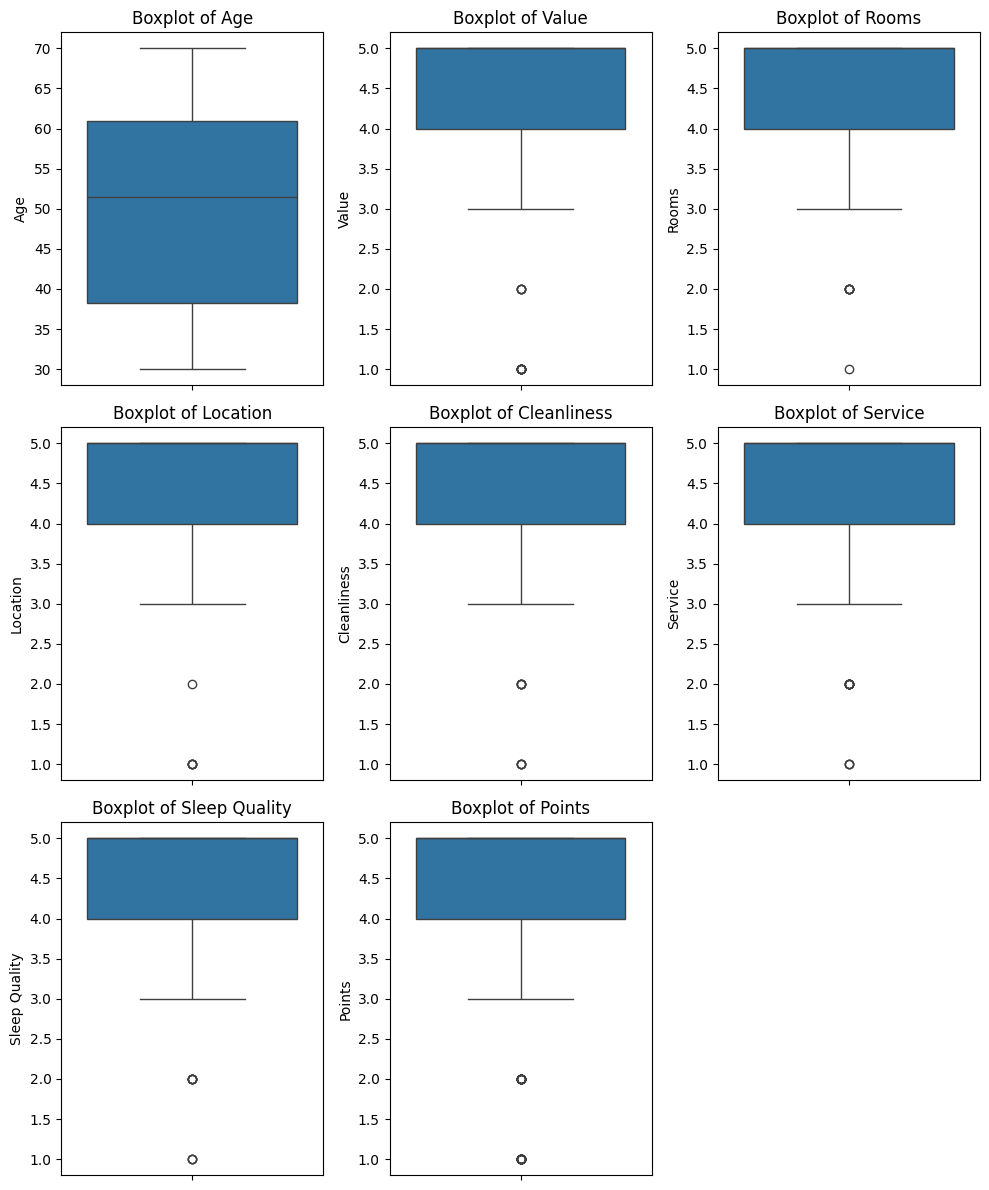

In [ ]:
# Busqueda de oitliers
numerical_features = ['Age', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep Quality', 'Points']

plt.figure(figsize=(10, 12)) # Increased figure height for more rows

# Changed subplot grid from 2x3 to 3x3 to accommodate all 9 features
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjusted grid size
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Se identificaron datos atípicos en la mayoría de las variables numéricas menos en Age, sin embargo, se tomó la decisión de estandarizarlas al momento de hacer cada uno de los modelos de clustering

In [ ]:
datos = pd.get_dummies(df, columns=['Contributions'], prefix='Contributions')

Se eliminó la variable que no se utilizará

##Clustering

###Kmeans

In [ ]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df_cat = df_imputed[['Age', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep Quality', 'Points']]
print(df_cat.head())

   Age     Value     Rooms  Location  Cleanliness   Service  Sleep Quality  \
0   68  5.000000  5.000000  5.000000      5.00000  5.000000       5.000000   
1   58  5.000000  5.000000  5.000000      5.00000  5.000000       5.000000   
2   44  1.000000  3.000000  3.000000      1.00000  1.000000       3.000000   
3   37  4.251969  4.456693  4.464567      4.47619  4.484848       4.507937   
4   50  4.251969  4.456693  4.464567      4.47619  4.484848       4.507937   

   Points  
0       5  
1       5  
2       2  
3       3  
4       5  


In [ ]:
corr_matrix = df_cat.corr()
corr_matrix

,Age,Value,Rooms,Location,Cleanliness,Service,Sleep Quality,Points
Age,1.000000,-0.126001,-0.032624,-0.047067,-0.092468,-0.112110,-0.103185,-0.082450
Value,-0.126001,1.000000,0.765236,0.763398,0.785420,0.905449,0.789865,0.515828
Rooms,-0.032624,0.765236,1.000000,0.733106,0.813791,0.777524,0.797914,0.497034
Location,-0.047067,0.763398,0.733106,1.000000,0.712329,0.674049,0.751152,0.441230
Cleanliness,-0.092468,0.785420,0.813791,0.712329,1.000000,0.842870,0.820461,0.504176
Service,-0.112110,0.905449,0.777524,0.674049,0.842870,1.000000,0.781126,0.517675
Sleep Quality,-0.103185,0.789865,0.797914,0.751152,0.820461,0.781126,1.000000,0.479249
Points,-0.082450,0.515828,0.497034,0.441230,0.504176,0.517675,0.479249,1.000000


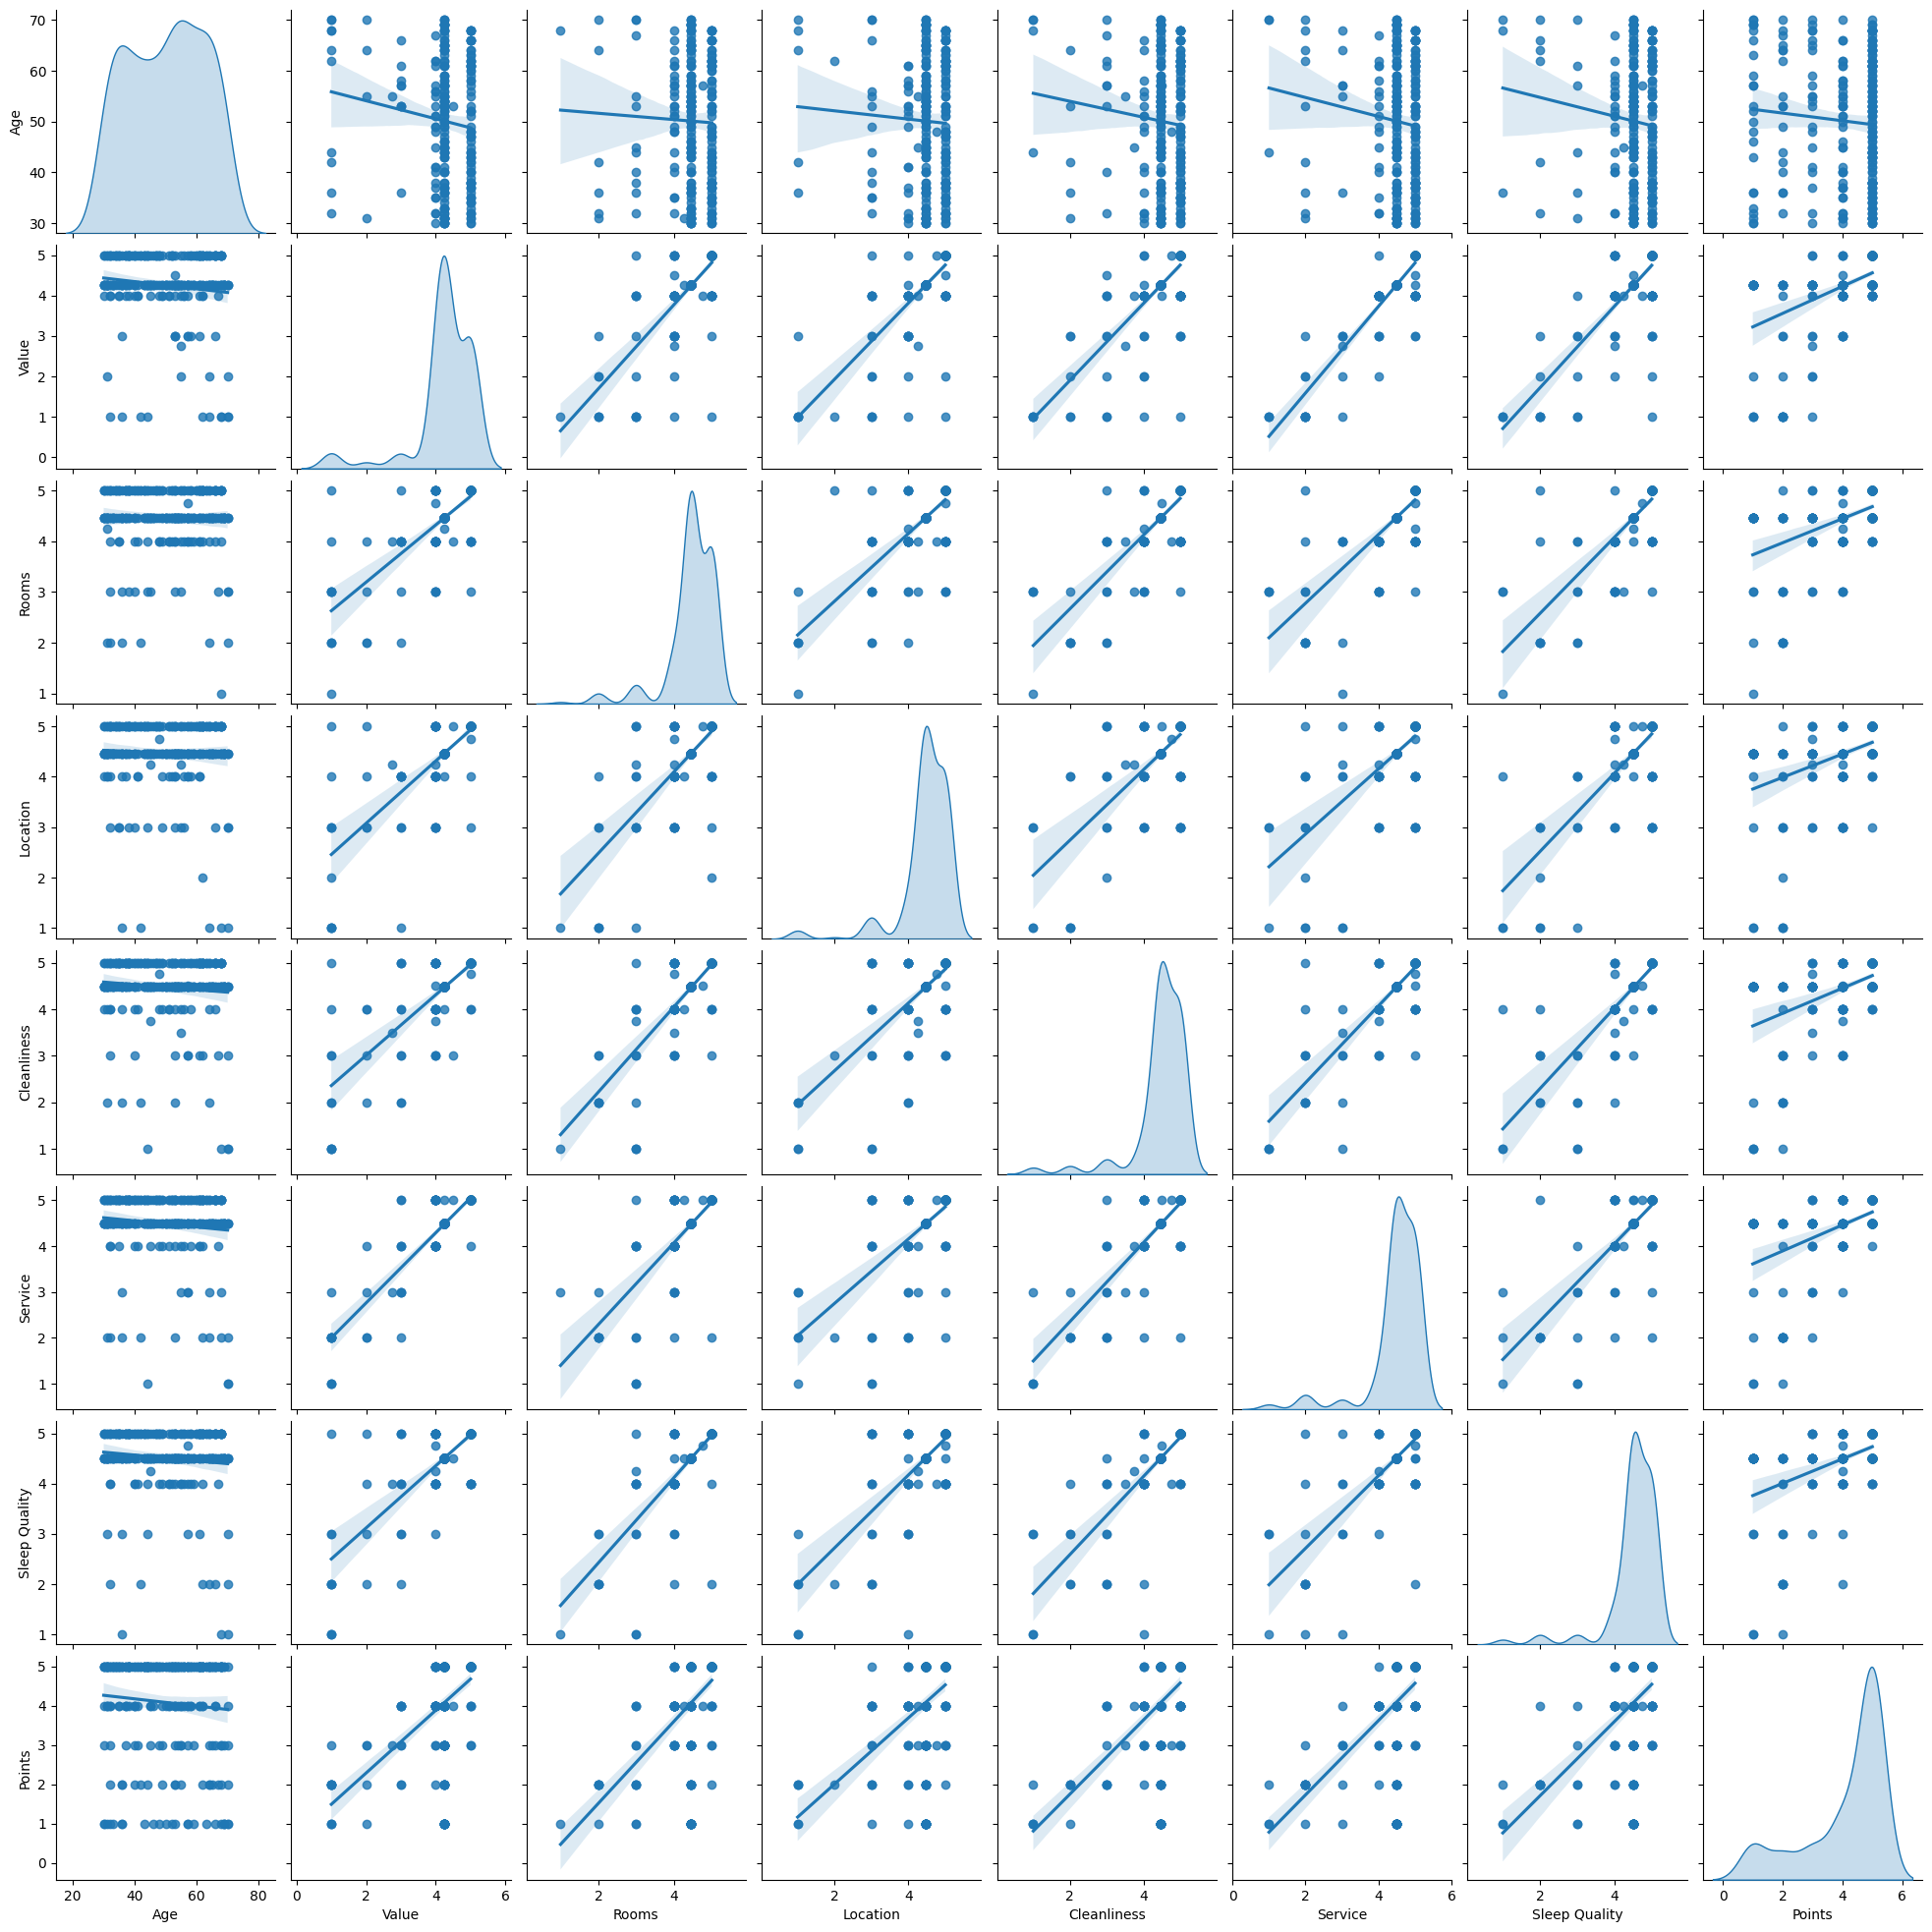

In [ ]:
sns.pairplot(df_cat, kind="reg", diag_kind="kde")
plt.show()

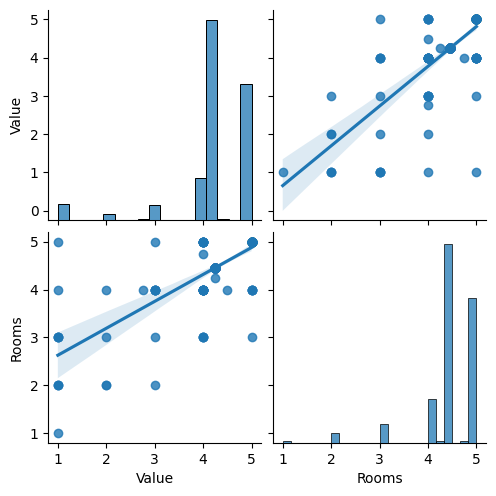

In [ ]:
sns.pairplot(df_cat[['Value','Rooms']], kind="reg")
plt.show()

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cat)


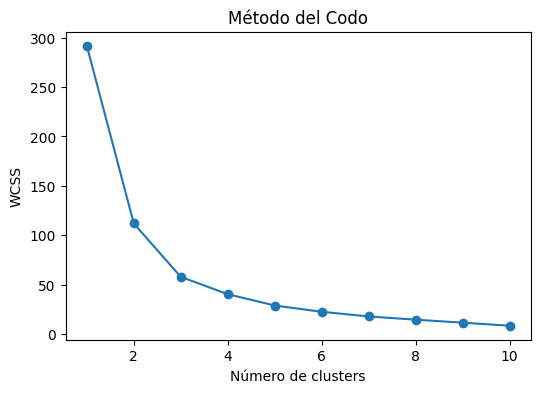

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_elbow.fit(df_cat)
    wcss.append(kmeans_elbow.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()


In [ ]:
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=500,  # Aumentamos significativamente el número de inicializaciones
    max_iter=300,
    random_state=42
)

In [ ]:
kmeans.fit(df_cat)

KMeans(n_clusters=2, n_init=500, random_state=42)

In [ ]:
labels = kmeans.labels_

In [ ]:
kmeans.inertia_

112.03801850225501

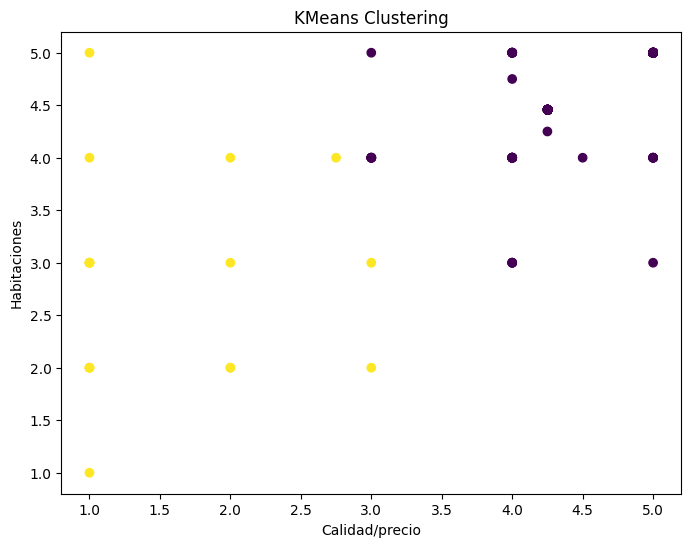

In [ ]:
# Visualizamos los clusters
plt.figure(figsize=(8, 6))
plt.scatter(df_cat['Value'], df_cat['Rooms'], c=labels, cmap='viridis')
plt.xlabel('Calidad/precio')
plt.ylabel('Habitaciones')
plt.title('KMeans Clustering')
plt.show()

Basándonos en el método del codo y en el tipo de información que tenemos, se decidió hacer 2 clúster. Tenemos una inertia de 112.04, lo que indica que cada cluster está cerca de sus centroides. Podemos ver que los clusters tienen una distribución marcada y uniforme, por lo que podemos decir que tienen características similares.

###DBSCAN


In [ ]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

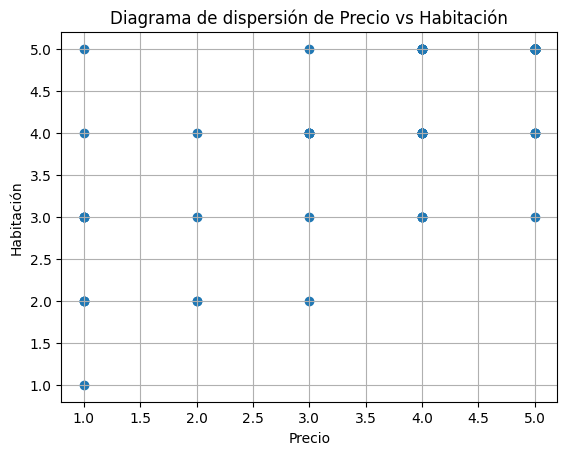

In [ ]:
plt.scatter(df['Value'], df['Rooms'])
plt.title('Diagrama de dispersión de Precio vs Habitación')
plt.xlabel('Precio')
plt.ylabel('Habitación')
plt.grid(True)

In [ ]:
data = df_imputed[['Value', 'Rooms']] # Select the relevant columns for clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data)

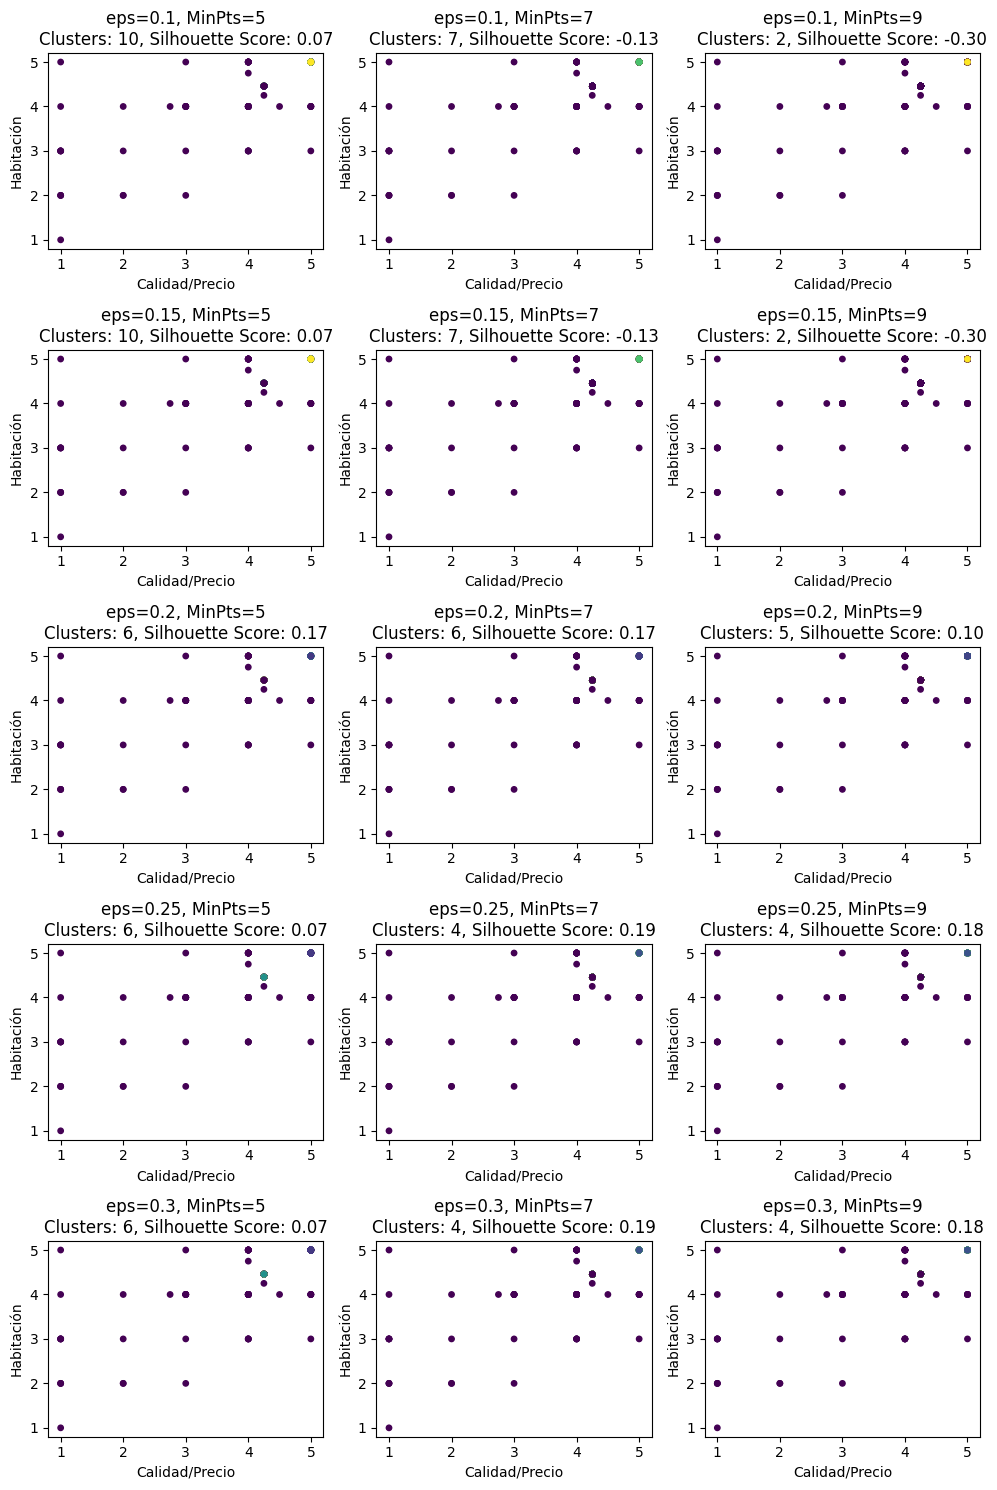

In [ ]:
eps_values = [0.1,0.15,0.2,0.25,0.3]
minPts_values = [5, 7, 9]

results = []
fig, axs = plt.subplots(len(eps_values), len(minPts_values), figsize=(10, 15))

for i, minPts in enumerate(minPts_values):
    for j, eps in enumerate(eps_values):

        dbscan_model = DBSCAN(eps=eps, min_samples=minPts)
        dbscan_labels = dbscan_model.fit_predict(scaled_features)

        # Check if there are at least 2 clusters before calculating silhouette score
        unique_labels = set(dbscan_labels)
        num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0) # Exclude noise (-1) from cluster count

        if num_clusters > 1:
            silhouette_avg = silhouette_score(scaled_features, dbscan_labels)
        else:
            silhouette_avg = np.nan  # Assign NaN if only one cluster is found

        axs[j, i].scatter(data['Value'], data['Rooms'], c=dbscan_labels, s=15)
        axs[j, i].set_title(f'eps={eps}, MinPts={minPts}\nClusters: {num_clusters}, Silhouette Score: {silhouette_avg:.2f}')
        axs[j, i].set_ylabel('Habitación')
        axs[j, i].set_xlabel('Calidad/Precio')


        results.append({
            'Epsilon (eps)': eps,
            'MinPts': minPts,
            'Silhouette Score': silhouette_avg,
            'Numero de clusters': num_clusters
        })

plt.tight_layout()
plt.show()

In [ ]:
results_df= pd.DataFrame(results)
results_df

,Epsilon (eps),MinPts,Silhouette Score,Numero de clusters
0,0.10,5,0.872356,6
1,0.15,5,0.872356,6
2,0.20,5,0.872356,6
3,0.25,5,0.872356,6
4,0.30,5,0.877563,6
5,0.10,7,0.817285,4
6,0.15,7,0.817285,4
7,0.20,7,0.817285,4
8,0.25,7,0.817285,4
9,0.30,7,0.839981,5


Text(0.5, 1.0, 'Desempeño de los modelos según el coeficiente de la silueta')

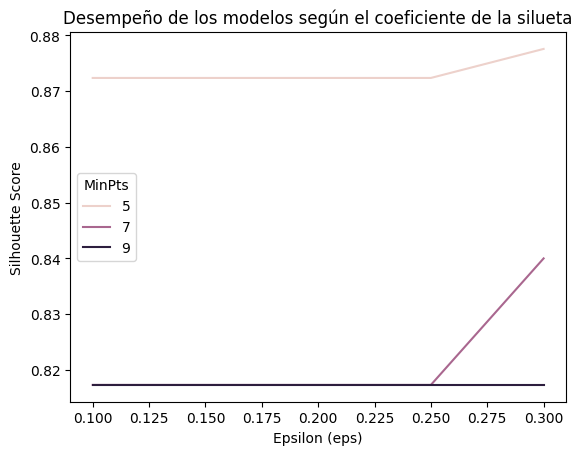

In [ ]:
sns.lineplot(x=results_df['Epsilon (eps)'], y=results_df['Silhouette Score'], hue=results_df['MinPts'])
plt.title('Desempeño de los modelos según el coeficiente de la silueta')

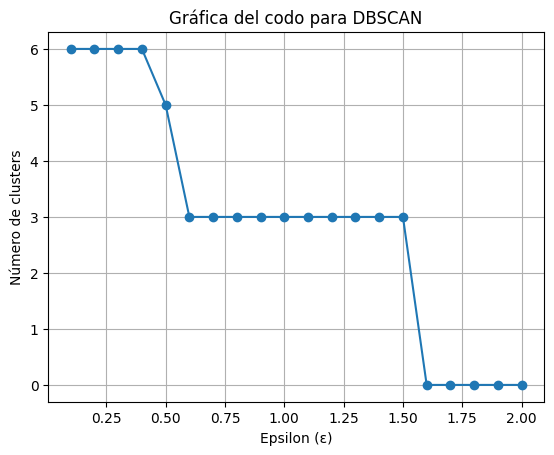

In [ ]:
epsilon_values = np.linspace(0.1, 2.0, 20)


num_clusters = []


for epsilon in epsilon_values:
    dbscan_model = DBSCAN(eps=epsilon)
    dbscan_labels = dbscan_model.fit_predict(scaled_features)


    num_clusters.append(len(np.unique(dbscan_labels)) - 1)


plt.plot(epsilon_values, num_clusters, marker='o')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Número de clusters')
plt.title('Gráfica del codo para DBSCAN')
plt.grid(True)
plt.show()

In [ ]:
db = DBSCAN(eps=0.3, min_samples=5).fit(scaled_features)

In [ ]:
df.loc[:, 'dbscan_labels'] = db.labels_

In [ ]:
df['dbscan_labels'].value_counts()

,count
dbscan_labels,
1,118
0,75
-1,25
5,11
3,9
4,7
2,5


In [ ]:
dbscan_labels = db.labels_
silhouette_avg = silhouette_score(scaled_features, dbscan_labels)
print("DBSCAN Silhouette Score:", silhouette_avg)

DBSCAN Silhouette Score: 0.8775631803538365


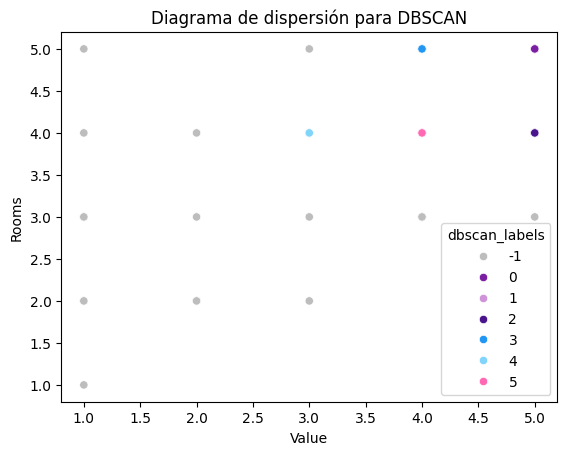

In [ ]:
custom_palette = {
    -1: '#BDBDBD',    # gris para el ruido
    0: '#7B1FA2',    # morado oscuro
    1: '#CE93D8',    # lavanda claro
    2: '#4A148C',    # morado profundo
    3: '#2196F3',    # azul medio
    4: '#81D4FA',    # azul celeste
    5: '#FF69B4',    # rosado fuerte

}

sns.scatterplot(data=df, x='Value', y='Rooms', hue='dbscan_labels', palette=custom_palette)
plt.title('Diagrama de dispersión para DBSCAN')
plt.show()

En el modelo DBSCAN, se decidió que los mejores valores para el modelo serían [eps=0.3, min_samples=5] con base a los gráficos. Se identificaron 6 clusteres no definidos y con un ruido muy grande, se obtuvo un coeficiente de silueta de 0.07 lo que confirma que no se definieron bien los clusters y que hay un solapamiento de los datos. Además, en el grafico final los datos no son capaces de distinguirse bien visualmente.

Teniendo en cuenta lo anterior se llega a la conclusión de que no es un buen modelo.


###Clustering Jerarquico

In [ ]:
df_scale = df_imputed[['Age', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep Quality', 'Points']] # Select the actual data from the DataFrame
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_scale) # Apply scaling to the data



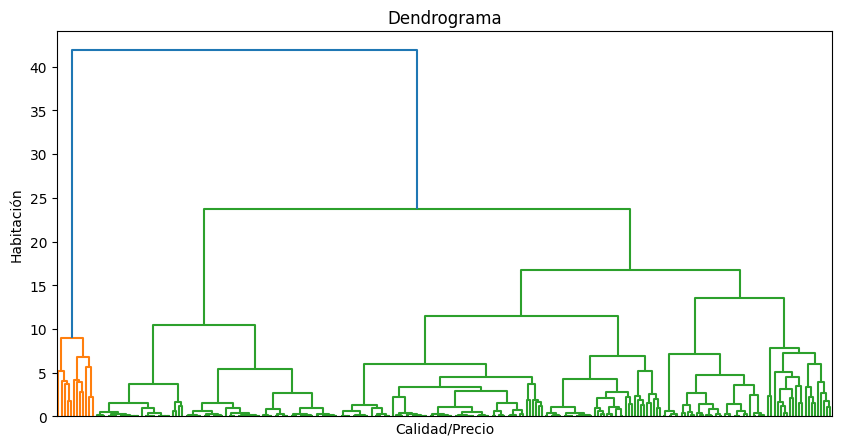

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# visualización clustering jerarquico
dist_matrix = linkage(scaled_features, method='ward')
# Visualizar el dendrograma
plt.figure(figsize=(10, 5))
dendrogram(dist_matrix,no_labels=True)
plt.title('Dendrograma')
plt.xlabel('Calidad/Precio')
plt.ylabel('Habitación')
plt.show()

En este modelo, la diferencia de altura entre los cortes indica que tan diferentes eran los grupos, por lo que viendo el grafico se puede llegar a la conclusión de que haciendo un corte a la altura de 30 hay 2 clúster principales

Finalmente, se llegó a la conclusión de que el mejor modelo es el Kmeans.

##Guardamos el modelo


In [ ]:
import joblib
# Guardar el modelo kmeans y sus parámetros
joblib.dump(kmeans, 'kmeans_model.pkl') # Se guarda el modelo de kmeans en el objeto 'kmeans_model.pkl'
joblib.dump(scaler, 'scaler.pkl') # Se guardan los parametros con los que se estandarizaron los datos con los que se entreno el modelo de kmeans

['scaler.pkl']

In [ ]:
# Calculamos las medias por clúster
cluster_means = df_cat.groupby(kmeans.labels_).mean()
cluster_means


,Age,Value,Rooms,Location,Cleanliness,Service,Sleep Quality,Points
0,49.793991,4.448422,4.578926,4.587206,4.614551,4.653271,4.639212,4.23176
1,54.117647,1.573529,2.823529,2.838235,2.558824,2.176471,2.764706,2.00000


El cluster 0 tiene una edad promedio es de 50 años y tienen las medias más altas en todas las categorías, por encima de 4.2. Este grupo representa a clientes satisfechos y que evalúan positivamente el servicio.

El cluster 1 tienen una edad promedio de 54 años, siendo un poco mayores a los del cluster 0. Tienen medias significativamente más bajas, de entre 1.6 y 2.8. Estos son clientes insatisfechos y que han tenido malas experiencias en varios aspectos.


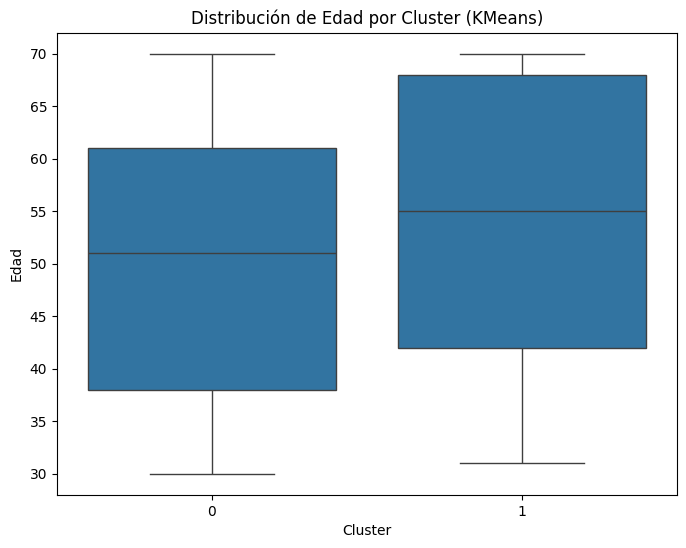

In [ ]:
# prompt: Boxplot de distribucion de edad por cluster

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Age'])
plt.title('Distribución de Edad por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Edad')
plt.show()


Ambos clusters tienen dispersiones considerables, el cluster 0 tiene una distribución ligeramente menor que el cluster 1 y una mediana un poco más baja.

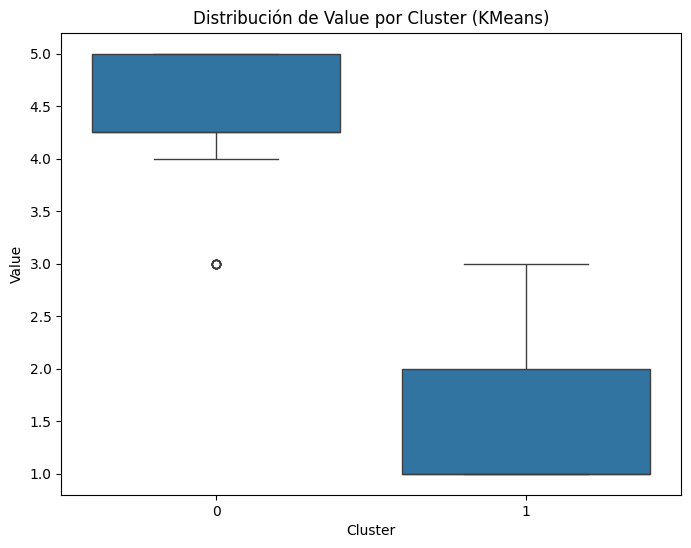

In [ ]:
#Distribucion de value

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Value'])
plt.title('Distribución de Value por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Value')
plt.show()

El cluster 0 tiene calores más altos que el cluster 1 y también una mediana más alta, lo que indica que percibieron una mayor relación de calidad precio con respecto a los del cluster 1, los cuales sintieron que el precio no justificó la experiencia recibida.

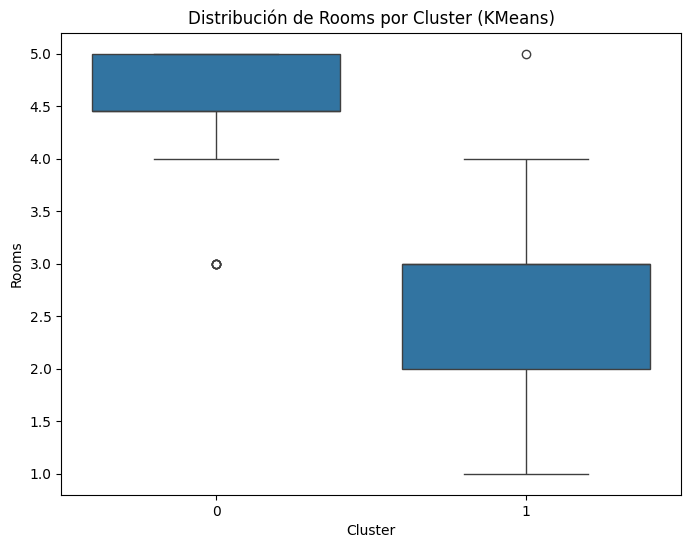

In [ ]:
#Distribucion de rooms

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Rooms'])
plt.title('Distribución de Rooms por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Rooms')
plt.show()

El cluster 0 calificó mejor las habitaciones que el cluster 1, indicando que tuvieron una mayor satisfacción.

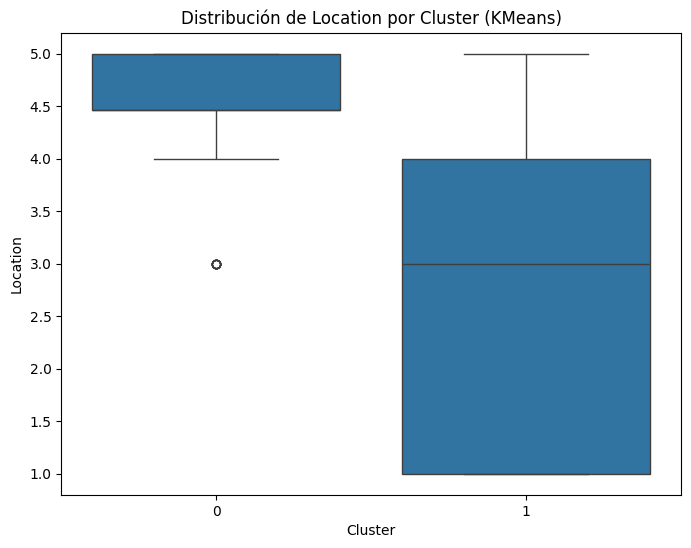

In [ ]:
#Distribucion de location

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Location'])
plt.title('Distribución de Location por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Location')
plt.show()

El cluster 0 tuvo una mayor satisfacción con la ubicación del hotel que el cluster 1, y relacionándolo con algunas de las reviews leídas antes de hacer el análisis, podemos concluir que el cluster 1 tuvo problemas con el ruido y la seguridad de la ubicación del hotel.

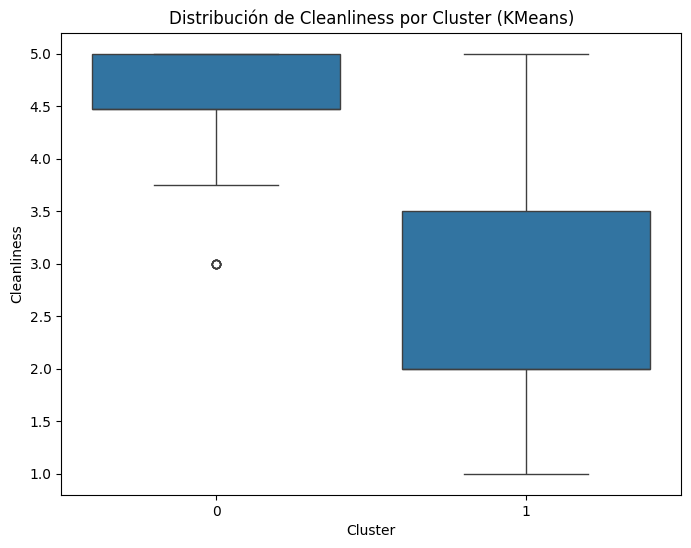

In [ ]:
#Distribucion de cleanliness

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Cleanliness'])
plt.title('Distribución de Cleanliness por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Cleanliness')
plt.show()

El cluster 0 percibió un mayor nivel de limpieza que el cluster 1, indicando que este es un punto esencial para mejorar en la atención del hotel.

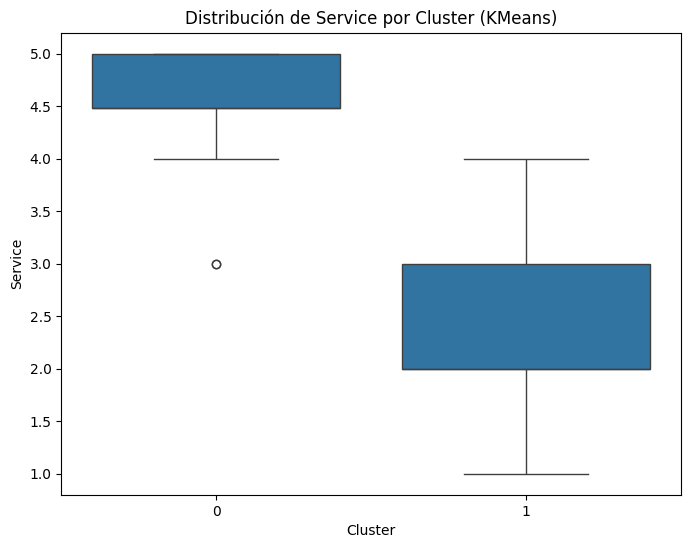

In [ ]:
#Distribucion de service

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Service'])
plt.title('Distribución de Service por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Service')
plt.show()

El cluster 0 calificó mejor el servicio que el cluster 1, indicando que todavía hay áreas de mejora en la prestación del servicio.

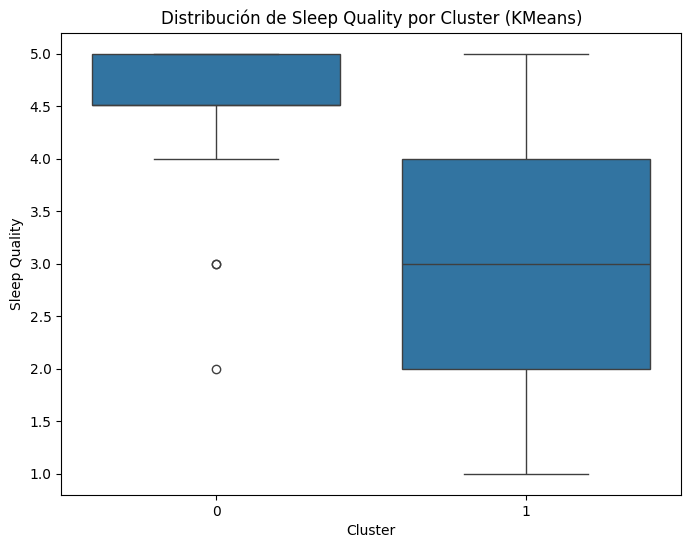

In [ ]:
#Distribucion de sleep quality

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Sleep Quality'])
plt.title('Distribución de Sleep Quality por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Sleep Quality')
plt.show()

El cluster 0 reportó una mayor calificación en la calidad del sueño a comparación del cluster 1, esto señala importantes áreas de insatisfacción con respecto al bienestar percibido.

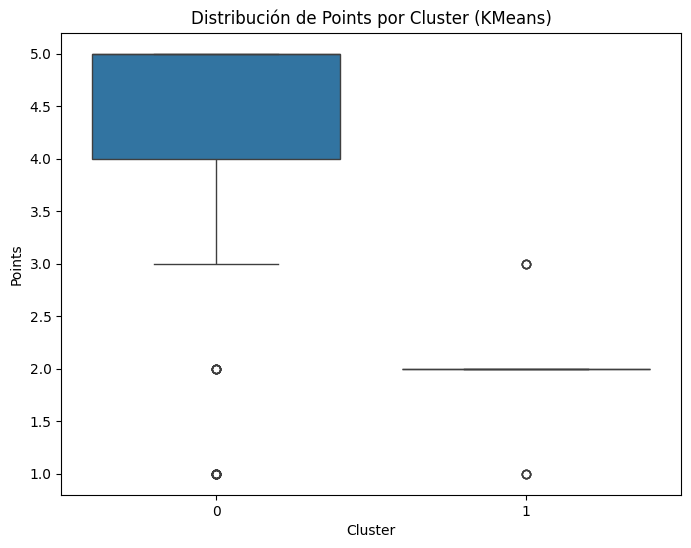

In [ ]:
#Distribucion de points

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.boxplot(x=kmeans.labels_, y=df_imputed['Points'])
plt.title('Distribución de Points por Cluster (KMeans)')
plt.xlabel('Cluster')
plt.ylabel('Points')
plt.show()

El cluster 0 calificó mejor el hotel mientras el cluster 1 lo calificó con una puntuación baja, indicando que algunos clientes no disfrutaron de su estadía, este resultado se vio reforzado con las experiencias en otras categorías.

## Informe ejecutivo

Se realizó una segmentación de clientes de la cual se obtuvieron 2 grupos diferenciados por la calificación de la percepción de calidad-precio y las habitaciones.

Los clientes del cluster 0 calificaron mejor puntos como las habitaciones, la buena ubicación, el nivel de limpieza, el servicio recibido y la calidad del sueño experimentada durante su estancia, indicando que estos estuvieron satisfechos y que consideran que el hotel cumple y/o excede con sus expectativas.

Por el contrario, en el cluster 1 se evidenciaron varios problemas como la falta de limpieza, ubicación problemática, deficiencias en el servicio al cliente y una mala calidad del sueño, indicando que estos clientes no disfrutaron su estadía y quedaron insatisfechos, sintiendo que la experiencia no justificó el precio.

Se recomienda priorizar aspectos fundamentales para cambiar las percepciones negativas como la limpieza y el servicio, además de implementar medidas de insonorización y seguridad para compensar los problemas con la ubicación del hotel. También, aplicar programas de fidelización para el cluster 0 como atención personalizada sirve para promover el hotel y las experiencias positivas.


#Analisis de Sentimientos


##Procesamiento de texto

In [ ]:
import pandas as pd # manejo de data frame
import numpy as np # manejos matriciales
import nltk # paquete 1 de lenguaje natural
import re # paquete 2 de lenguaje natural
from nltk.corpus import stopwords # conjunto de stopwords
from nltk.tokenize import TweetTokenizer # tokenizador de tweet
from nltk.stem import PorterStemmer # hacer steming palabras
from nltk.stem import LancasterStemmer # hacer steming palabras
from nltk.stem import WordNetLemmatizer # extraer el lema de una palabra
import matplotlib.pyplot as plt
from wordcloud import WordCloud  # graficos de palabras

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')
import pandas as pd
from textblob import TextBlob
import csv
import re
import time
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
df["Reviews"]

,Reviews
0,Very good service\nExceptional care from Nidia...
1,"Yep, think we found the place in Cartegena!\nT..."
2,avoid this place\nDon't come here. I booked a...
3,Beautiful area. Disappointing for a Hilton\nTh...
4,Excellent hotel in Cartagena\nExtraordinary ho...
...,...
245,The breakfast area and service is the worst of...
246,This hotel is a short drive outside the old wa...
247,"good hotel, you have beach, pools, restaurants..."
248,"Great hotel, great location, great staff, can’..."


In [ ]:
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download the necessary Punkt model
nltk.download('punkt_tab')

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

# Assuming 'datos' DataFrame exists
df['Reviews'] = df['Reviews'].apply(remove_stopwords)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def clean_text(text):
  text = re.sub(r'^RT[\s]+', '', text)
  text = re.sub(r'https?:\/\/.*[\r\n]*', '', text)
  text = re.sub(r'#', '', text)
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  return text

In [ ]:
df['clean_text'] = df["Reviews"].apply(clean_text)

In [ ]:
df['clean_text']

,clean_text
0,good service Exceptional care Nidia stay Hilto...
1,"Yep , think found place Cartegena ! HusBenn Ca..."
2,avoid place n't come . booked corner room terr...
3,Beautiful area . Disappointing Hilton Hilton C...
4,Excellent hotel Cartagena Extraordinary hotel ...
...,...
245,breakfast area service worst many Hilton visit...
246,"hotel short drive outside old walled city , pr..."
247,"good hotel , beach , pools , restaurants . ext..."
248,"Great hotel , great location , great staff , ’..."


In [ ]:
import re

def clean_text(text):
  text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
  text = re.sub(r'\d+', '', text) # Remove numbers
  text = text.lower() # Convert to lowercase
  return text

df['clean_text'] = df['Reviews'].apply(clean_text)



In [ ]:
df['clean_text']

,clean_text
0,good service exceptional care nidia stay hilto...
1,yep think found place cartegena husbenn cart...
2,avoid place nt come booked corner room terrac...
3,beautiful area disappointing hilton hilton ca...
4,excellent hotel cartagena extraordinary hotel ...
...,...
245,breakfast area service worst many hilton visit...
246,hotel short drive outside old walled city pri...
247,good hotel beach pools restaurants extra p...
248,great hotel great location great staff say...


In [ ]:
import re

def remove_emojis(text):
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r'', text)

df['clean_text'] = df['clean_text'].apply(remove_emojis)
df['clean_text']

,clean_text
0,good service exceptional care nidia stay hilto...
1,yep think found place cartegena husbenn cart...
2,avoid place nt come booked corner room terrac...
3,beautiful area disappointing hilton hilton ca...
4,excellent hotel cartagena extraordinary hotel ...
...,...
245,breakfast area service worst many hilton visit...
246,hotel short drive outside old walled city pri...
247,good hotel beach pools restaurants extra p...
248,great hotel great location great staff say...


##Analisis de sentimientos con text blob

In [ ]:
from textblob import TextBlob
def get_polarity(text):
  analysis = TextBlob(text).sentiment
  return analysis.polarity

In [ ]:
df['polarity'] = df['clean_text'].apply(get_polarity)

In [ ]:
df['polarity'].head()

,polarity
0,0.389583
1,0.291667
2,-0.212500
3,-0.074405
4,0.600680


In [ ]:
df[df.polarity < 0.3][['Reviews', 'polarity']].head()

,Reviews,polarity
1,"Yep , think found place Cartegena ! HusBenn Ca...",0.291667
2,avoid place n't come . booked corner room terr...,-0.212500
3,Beautiful area . Disappointing Hilton Hilton C...,-0.074405
5,"Nothing world good location want enjoy pools ,...",0.128402
8,Ca n't wait get back birthday Sep frequent Car...,0.150000


In [ ]:
def x_range(x):
  if x > 0:
    return 1
  elif x == 0:
    return 0
  else:
    return -1

df['sentiment'] = df['polarity'].apply(x_range)
df.head(3)

,Name,Age,Contributions,Year,Month,Trip Type,Value,Rooms,Location,Cleanliness,Service,Sleep Quality,Points,Reviews,dbscan_labels,clean_text,polarity,sentiment
0,Gaspar T,68,1,2025,May,Family,5.0,5.0,5.0,5.0,5.0,5.0,5,good service Exceptional care Nidia stay Hilto...,0,good service exceptional care nidia stay hilto...,0.389583,1
1,Kawanda S-Pryor,58,137,2024,Feb,Friends,5.0,NaN,5.0,NaN,5.0,NaN,5,"Yep , think found place Cartegena ! HusBenn Ca...",0,yep think found place cartegena husbenn cart...,0.291667,1
2,jimmyktown,44,85,2025,May,Business,1.0,3.0,3.0,1.0,1.0,3.0,2,avoid place n't come . booked corner room terr...,-1,avoid place nt come booked corner room terrac...,-0.212500,-1


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
1,217
-1,33


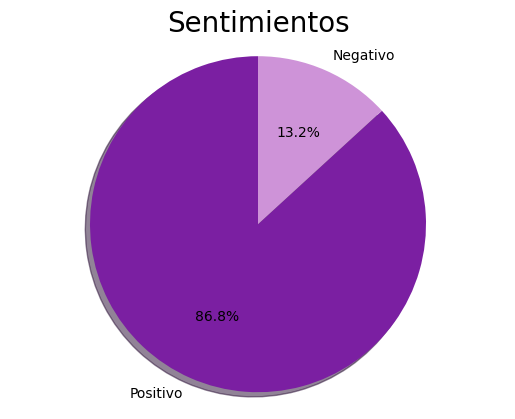

In [ ]:
import matplotlib.pyplot as plt
labels = 'Positivo', 'Negativo'
colors = ["#7B1FA2", "#CE93D8"]
plt.pie(df['sentiment'].value_counts(), labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)
plt.title('Sentimientos', fontsize = 20)
plt.axis('equal')
plt.show()

La mayoria de las opiniones son positivacon un 86.8% frente al 13.2% de las negativas.

In [ ]:
import matplotlib.pyplot as plt
def get_satisfaction_level(sentiment):
  if sentiment == 1:
    return 'Satisfecho'
  elif sentiment == 0:
    return 'Neutral'
  else:
    return 'Insatisfecho'

df['nivel_satisfaccion'] = df['sentiment'].apply(get_satisfaction_level)

print("Nivel de Satisfacción de los Clientes:")
print(df['nivel_satisfaccion'].value_counts())

print(df[['Reviews', 'polarity', 'nivel_satisfaccion']].head())



Nivel de Satisfacción de los Clientes:
nivel_satisfaccion
Satisfecho      217
Insatisfecho     33
Name: count, dtype: int64
                                             Reviews  polarity  \
0  good service Exceptional care Nidia stay Hilto...  0.389583   
1  Yep , think found place Cartegena ! HusBenn Ca...  0.291667   
2  avoid place n't come . booked corner room terr... -0.212500   
3  Beautiful area . Disappointing Hilton Hilton C... -0.074405   
4  Excellent hotel Cartagena Extraordinary hotel ...  0.600680   

  nivel_satisfaccion  
0         Satisfecho  
1         Satisfecho  
2       Insatisfecho  
3       Insatisfecho  
4         Satisfecho  


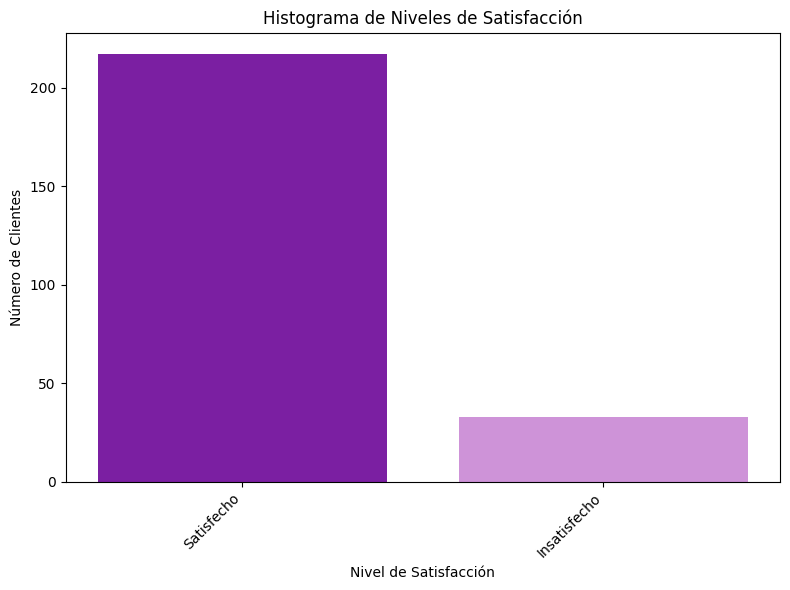

In [ ]:
# prompt: histograma de niveles de satisfacción

import matplotlib.pyplot as plt

# Count the occurrences of each satisfaction level
satisfaction_counts = df['nivel_satisfaccion'].value_counts()

# Create the histogram
plt.figure(figsize=(8, 6))
plt.bar(satisfaction_counts.index, satisfaction_counts.values, color=["#7B1FA2", "#CE93D8"])
plt.xlabel("Nivel de Satisfacción")
plt.ylabel("Número de Clientes")
plt.title("Histograma de Niveles de Satisfacción")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Se crearon 3 niveles de satisfacción (satisfecho, neutral e insatisfecho), de los cuales las reviews se concentraron solo en 2 de ellos. 217 mensajes se encuentran en satisfecho y 33 en insatisfecho.

In [ ]:
from wordcloud import WordCloud
text = ' '.join(df.clean_text)
text

'good service exceptional care nidia stay hilton hotel  pleasantly surprised kindness professionalism waitress nidia  attentive  always smile willing help times  warmth made experience much enjoyable  thanks making feel home  personnel like make difference  yep  think found place cartegena  husbenn cartegena th birthday celebration friends  first days  stayed airbnb everyone great  airbnb smack dab middle getsemani area everything walking distance  last night  book hotel soooooooo glad  hilton gave us everything needed  ocean view room  hospitality food  hilton icing top great trip  sooooo glad last day night spent  romantic  exactly needed end greaaaaaaat trip  avoid place nt come  booked corner room terrace  arrived nt ready manager lied told take considerably worse room paid  nightmare started  three hours  got room  someone else s pubic hairs covering bathroom weak air conditioner  poor restaurant  bad management  hugely overpriced    us night go elsewhere beautiful area  disappoin

In [ ]:
wordcloud = WordCloud(width=1024, height=800, colormap='Purples', min_font_size=14).generate(text)

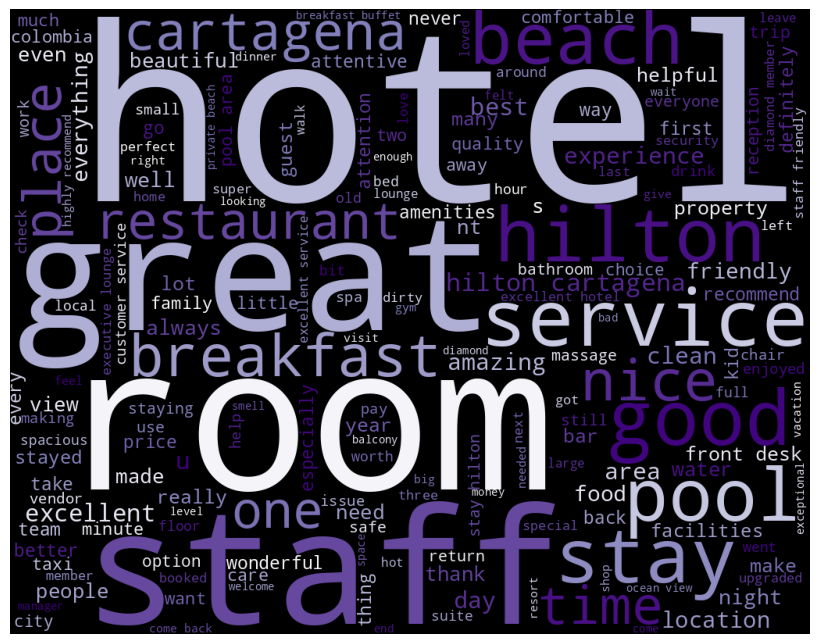

In [ ]:
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

Las palabras más usadas en todas las reviews fueron hotel, great, room, staff, hilton, service, stay, pool, restaurant y breakfast.

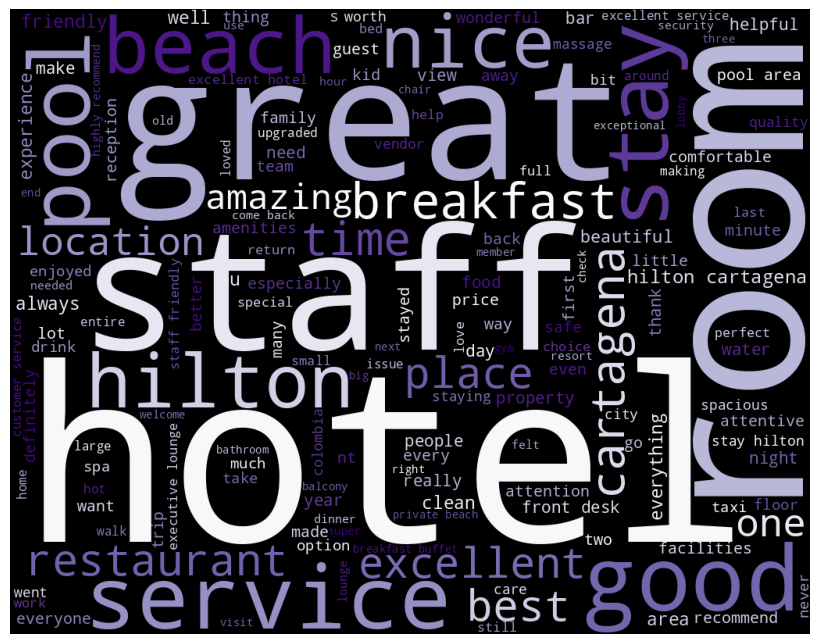

In [ ]:
#Palabras que más se repiten en la categoria satisfecho
text = ' '.join(df[df['nivel_satisfaccion'] == 'Satisfecho'].clean_text)
wordcloud = WordCloud(width=1024, height=800, colormap='Purples', min_font_size=14).generate(text)
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()


Las palabras más usadas en el nivel "Satisfecho" fueron hotel, staff, great, room, hilton, service, good, pool, nice y beach.

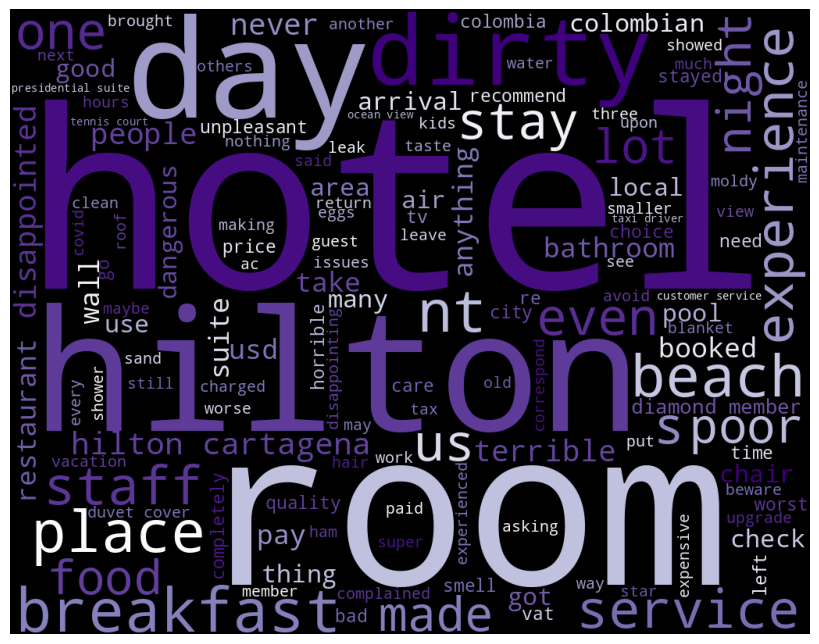

In [ ]:
# Palabras que más se repiten en la categoria insatisfecho
text = ' '.join(df[df['nivel_satisfaccion'] == 'Insatisfecho'].clean_text)
wordcloud = WordCloud(width=1024, height=800, colormap='Purples', min_font_size=14).generate(text)
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


Las palabras más usadas en el nivel "Insatisfecho" fueron hotel, hilton, room, day, dirty, breakfast, service, beach, poor y place

Nivel de Satisfacción del Cluster 0:
nivel_satisfaccion
Satisfecho      212
Insatisfecho     21
Name: count, dtype: int64


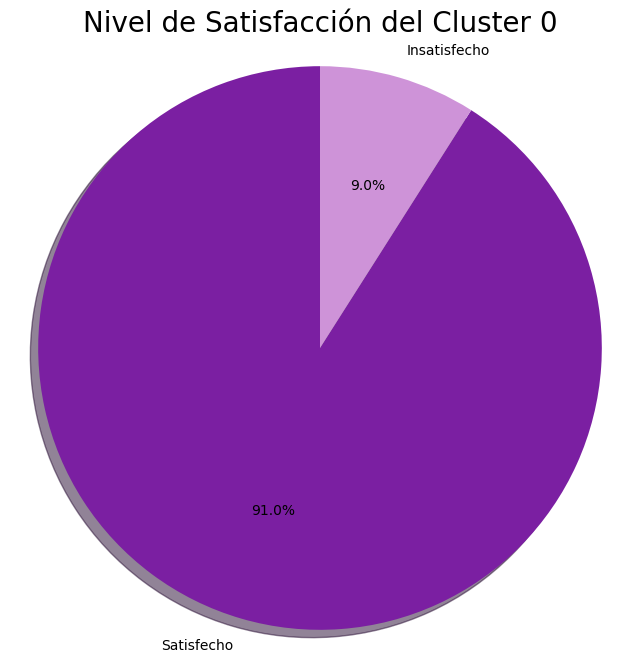

In [ ]:
#Nivel de satisfacción del cluster 1

import matplotlib.pyplot as plt
cluster_0_data = df[kmeans.labels_ == 0]

satisfaction_counts_cluster_0 = cluster_0_data['nivel_satisfaccion'].value_counts()

print("Nivel de Satisfacción del Cluster 0:")
print(satisfaction_counts_cluster_0)

labels_cluster_1 = satisfaction_counts_cluster_0.index
sizes_cluster_1 = satisfaction_counts_cluster_0.values
colors_cluster_1 = ["#7B1FA2", "#CE93D8"]

plt.figure(figsize=(8, 8))
plt.pie(sizes_cluster_1, labels=labels_cluster_1, colors=colors_cluster_1,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Nivel de Satisfacción del Cluster 0', fontsize=20)
plt.axis('equal')
plt.show()


En el cluster 0, el 91% de los clientes estuvieron satisfechos, mientras el 9% no lo estuvieron

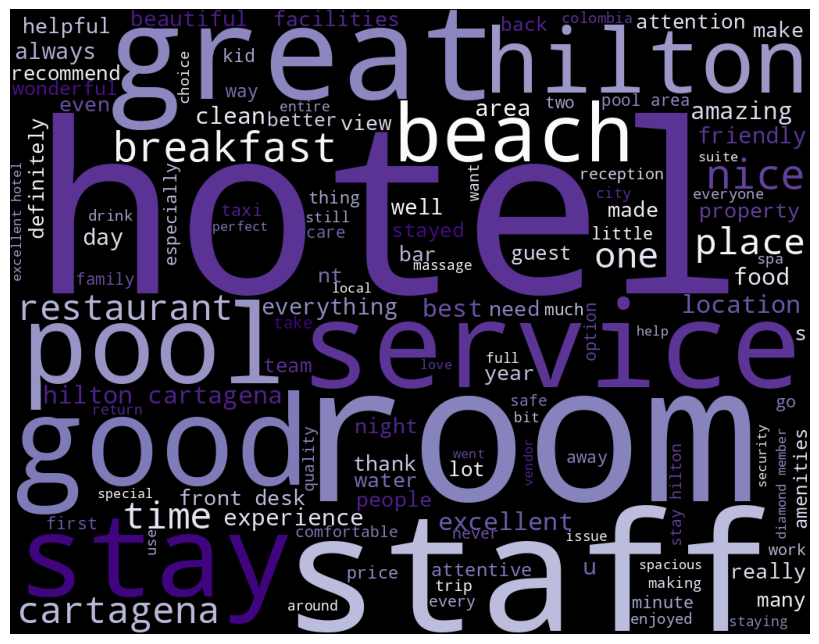

In [ ]:
#Palabras más repetidas en el cluster 0

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

text = ' '.join(df[kmeans.labels_ == 0]['clean_text'])
wordcloud = WordCloud(width=1024, height=800, colormap='Purples', min_font_size=14).generate(text)
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

Las palabras que más se repitieron en el cluster 0 fueron hotel, room, staff, great, good, pool, service, stay, hilton y beach

Nivel de Satisfacción del Cluster 1:
nivel_satisfaccion
Insatisfecho    12
Satisfecho       5
Name: count, dtype: int64


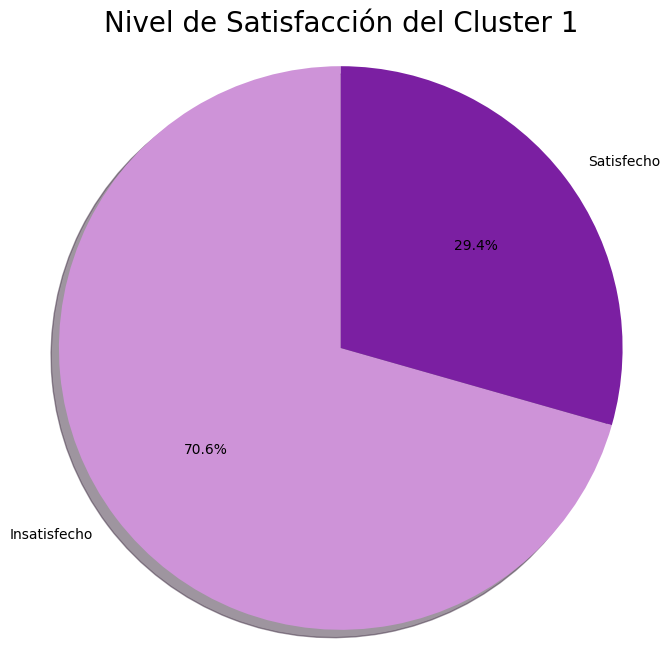

In [ ]:
#Nivel de satisfacción del cluster 1

import matplotlib.pyplot as plt
cluster_1_data = df[kmeans.labels_ == 1]

satisfaction_counts_cluster_1 = cluster_1_data['nivel_satisfaccion'].value_counts()

print("Nivel de Satisfacción del Cluster 1:")
print(satisfaction_counts_cluster_1)

labels_cluster_1 = satisfaction_counts_cluster_1.index
sizes_cluster_1 = satisfaction_counts_cluster_1.values
colors_cluster_1 = ["#CE93D8", "#7B1FA2"]

plt.figure(figsize=(8, 8))
plt.pie(sizes_cluster_1, labels=labels_cluster_1, colors=colors_cluster_1,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Nivel de Satisfacción del Cluster 1', fontsize=20)
plt.axis('equal')
plt.show()


En el cluster 1, el 70.6% de los clientes estuvieron insatisfechos, mientras el 29.4% estuvieron satisfechos.

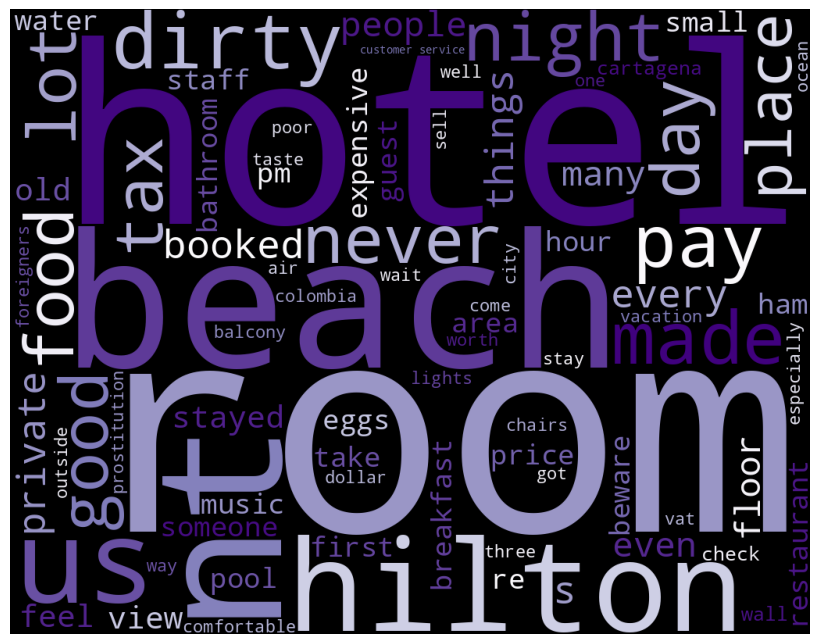

In [ ]:
#Palabras más repetidas en el cluster 1

import matplotlib.pyplot as plt
from wordcloud import WordCloud
text = ' '.join(df[kmeans.labels_ == 1]['clean_text'])
wordcloud = WordCloud(width=1024, height=800, colormap='Purples', min_font_size=14).generate(text)
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

Las palabras que más se repitieron en el cluster 1 fueron room, hotel, beach, hilton, us, dirty, never, night, lot y pay.

## Informe ejecutivo